In [18]:
import jax.numpy as jnp
from jax import random, jit, lax
import matplotlib.pyplot as plt
import time

In [19]:
# 1. Setup Parameters
N, K = 100, 2.0
dt, steps = 0.1, 2000

# Initialize Random Keys
key = random.PRNGKey(42)
k1, k2 = random.split(key)

# Generate natural frequencies (omega) and initial phases (theta)
omega = random.normal(k1, (N,))
init_theta = random.uniform(k2, (N,), minval=0, maxval=2*jnp.pi)

In [20]:
# 2. Define the "Scan-friendly" RK4 Step
def simulation_step(theta, _):
    """
    theta: the 'carry' (current phases)
    _: the 'x' (a dummy input since we don't need external values)
    """
    # Derivative function (Kuramoto interaction)
    def f(th): 
        # Broadcasting th[None, :] - th[:, None] creates the pairwise N x N interaction matrix
        return omega + (K/N) * jnp.sin(th[None, :] - th[:, None]).sum(axis=1)
    
    # 4th-Order Runge-Kutta (RK4) integration
    k1 = f(theta)
    k2 = f(theta + dt/2 * k1)
    k3 = f(theta + dt/2 * k2)
    k4 = f(theta + dt * k3)
    next_theta = theta + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    
    # Calculate the Order Parameter r(t) = |1/N * sum(e^(i*theta))|
    z = jnp.mean(jnp.exp(1j * theta))
    r = jnp.abs(z)
    
    # Return (state_for_next_step, value_to_save_in_history)
    return next_theta, r

In [21]:
@jit
def run_full_simulation(initial_theta):
    # lax.scan(function, initial_state, sequence_of_steps)
    final_theta, r_history = lax.scan(simulation_step, initial_theta, jnp.arange(steps))
    return final_theta, r_history

In [22]:
start = time.perf_counter()

# 1. Get the results (this returns immediately due to async dispatch)
final_theta, r_history = run_full_simulation(init_theta)

# Force JAX to wait until the computation is physically finished on the hardware
r_history.block_until_ready() 

end = time.perf_counter()

print(f"Execution time: {end - start:.4f} seconds")

Execution time: 1.1404 seconds


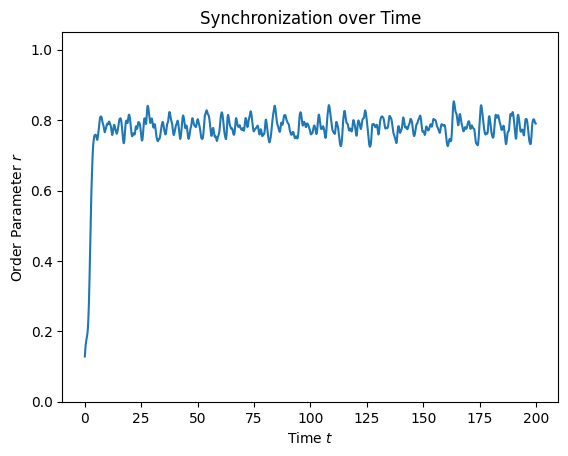

In [23]:
# --- Plotting ---
# Convert iterations to time by multiplying by dt (0.1)
plt.plot(jnp.arange(steps) * dt, r_history, label='JAX Order Parameter $r(t)$')
plt.xlabel("Time $t$")
plt.ylabel("Order Parameter $r$")
plt.title("Synchronization over Time")
plt.ylim(0, 1.05)
plt.show()